STP-RRT* algorithm gives the CasADi solver an initial guess for the optimal path

In [23]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import STP_RRTStar
import Dynamic
import numpy as np
import casadi as ca
import matplotlib.patches as patches
from IPython.display import HTML
from scipy.interpolate import splprep, splev
import importlib
import csv
import json
from scipy.interpolate import interp1d
from Camera import Camera
import time
import convex_map # <--- NEW IMPORT

In [24]:
importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as Rrt

In [ ]:
# Importing simulation parameters and generated paths from Jefferson
path_type_string = "naive"
scenario_key = "0" # 1 for 11/7/25 animation
# 0 for 12/10/25 animation
# 0 was used for time penalty tuning, it also has an initial guess for every path type

# Defender and map info
with open("2D_Comparison_Defender_Map.json", "r") as f:
    defender_data = json.load(f)

# path info
with open("2D_Comparison_Path.json", "r") as f:
    path_data = json.load(f)

'''STP-RRT stuff'''
# Attacker Position
# map_size_original = [0, 100, 0, 100] # [-x, x, -y, y]
# map_translate = [0, 0]
# map_size = [map_size_original[0]-map_translate[0], map_size_original[1]-map_translate[0], map_size_original[2]-map_translate[1], map_size_original[3]-map_translate[1]]
x0_1 = [5, 5, 0] # Start [x, y, t]
x0list = [x0_1] 
xf = [95,95] # Goal [x, y] (t doesn't matter)

# Replace the manual map setup with the call to convex_map.generate_map
MAP_W, MAP_H = 100.0, 100.0
map_size_original = [0, MAP_W, 0, MAP_H] # [-x, x, -y, y]

# list of camera x and y positions
# cam_x = [3, 6, 7, 5]
# cam_y = [8, 4, 2, 1]
cam_x = defender_data[scenario_key]["x"]
cam_y = defender_data[scenario_key]["y"]


dynamic_obstacle_pos = []

for i in range(len(cam_x)):
    dynamic_obstacle_pos.append([cam_x[i], cam_y[i]])

num_cams = len(cam_x) # loaded from file
num_obs = 7 # number of obstacles on the map
# 7 used for 12/12/25 animation

# Generate the map using the new function
map_in_full, cam_dict_full = convex_map.generate_map(
    map_size=(MAP_W, MAP_H),
    num_buildings=num_obs, # Reduced for initial test (tune this)
    num_sensors=num_cams,   # Number of PTZ cameras
    rng_seed=7 #7 for 11/7/25 animation and 12/10/25 animation
)

# Extract map_in and cam_dict in the expected format
map_in = {
    'st': map_in_full['st'],
    'n': map_in_full['n'],
    'ncam': map_in_full['ncam']
}
cam_dict = cam_dict_full

# Re-define map_size for CasADi bounds
map_size = [map_in['st']['size'][0], map_in['st']['size'][1], map_in['st']['size'][2], map_in['st']['size'][3]]


prox = [10, 1] # proximity for connection [position, time] 

# General RRT Settings
iter_max = 1000     # maximum number of iterations for the tree
vmax = 10            # max velocity for each point
max_time = 1        # max time difference for each point

# Test case
# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1
t = [10, 1, 500] # [camera_period, camera_increment, some unused variable]

# # Map
# map_in = {}
# # Static Map
# map_in['st'] = {}
# map_in['st']['size'] = np.array([map_size[0], map_size[1], map_size[2], map_size[3]])
# # Single building example
# # This is an imaginary cylinder around the camera tripod position
# # Collision radius r_cyl = 250 [mm]
# # [center_x, center_y, radius]
# r_cyl = 1
# map_in['st']['n'] = len(cam_x)
# for i in range(len(cam_x)):
#     map_in['st'][str(i)] = np.array([cam_x[i], cam_y[i], r_cyl])

# # map_in['st']['0'] = np.array([cam_x[0], cam_y[0], r_cyl])
# # map_in['st']['1'] = np.array([cam_x[1], cam_y[1], r_cyl])
# # map_in['st']['2'] = np.array([cam_x[2], cam_y[2], r_cyl])


# # Dynamic Map
# # This is a continuous function that generates camera FOV coverages
# # Input is map_in, and time input t_in
# map_in['n'] = t[0] # camera period

# Camera Position
cam_dict = {}
cam_dict['n'] = len(cam_x)
map_in['ncam'] = len(cam_x)
cam_dict['x'] = cam_x
cam_dict['y'] = cam_y

# # Surveillance Pattern Parameters
# tilt_limit = [] #[lower, upper]
# tilt_limit.append([np.deg2rad(0), np.deg2rad(90)])
# tilt_limit.append([np.deg2rad(90), np.deg2rad(180)])
# tilt_limit.append([np.deg2rad(180), np.deg2rad(270)])
# tilt_limit.append([np.deg2rad(225), np.deg2rad(315)])

# init_angles = []
# for i in range(len(cam_x)):
#     init_angles.append((tilt_limit[i][0]+tilt_limit[i][1])/2)
# # init_angles = [(tilt_limit[0][0]+tilt_limit[0][1])/2, (tilt_limit[1][0]+tilt_limit[1][1])/2, (tilt_limit[2][0]+tilt_limit[2][1])/2] 
# # ^^^ Currently setting these to be the midpoints of the angluar range ^^^


# # Camera Spec
# cam_period = t[0]
# cam_increment = t[1]
# cam_dict['spec']['init_angle'] = init_angles
# cam_dict['spec']['bound'] = tilt_limit
# cam_dict['spec']['fov'] = [fov_ang, fov_rng]
# cam_dict['spec']['cam_time'] = [cam_period, cam_increment]

# For Monte Carlo simulation, this is all loaded from Jefferson's file:
cam_dict['spec'] = {}
cam_dict['spec']['init_angle'] = defender_data[scenario_key]["spec"]["init_angle"]
cam_dict['spec']['bound'] = defender_data[scenario_key]["spec"]["bound"]              
cam_dict['spec']['fov'] = defender_data[scenario_key]["spec"]["fov"]
cam_dict['spec']['cam_time'] = defender_data[scenario_key]["spec"]["cam_time"]
cam_dict['spec']['panspeed'] = defender_data[scenario_key]["spec"]["panspeed"]

# Importing fov angle and range from Jefferson's results
fov_ang = cam_dict['spec']['fov'][0]
fov_rng = cam_dict['spec']['fov'][1]


cameras_dict_copilot = []
for i in range(cam_dict['n']):
    cam_x_dict = cam_dict['x'][i]
    cam_y_dict = cam_dict['y'][i]
    lower = cam_dict['spec']['bound'][i][0]
    upper = cam_dict['spec']['bound'][i][1]
    amplitude = 0.5 * (upper - lower)
    center = cam_dict['spec']['init_angle'][i] # ASSUMING THAT INITIAL ANGLE IS CENTER ANGLE
    period = cam_dict['spec']['cam_time'][0]
    frequency = 1 / period  # Use Hz for animation
    init_angle = cam_dict['spec']['init_angle'][i]
    # phase_offset = np.arctan2(init_angle - center, amplitude)
    phase_offset = 0 # Assuming that all cameras start at center of angular range
    panspeed = cam_dict['spec']['panspeed'][i]

    cameras_dict_copilot.append({
        'pos': [cam_x_dict, cam_y_dict],
        'amplitude': amplitude,
        'frequency': frequency,
        'phase': phase_offset,
        'center': center,
        'range': fov_rng,
        'panspeed': panspeed
    })


# Test dynamic map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# STP-RRT* Execution parameters
x0 = x0list[0]          # start point
nPartition = 5          # number of trees from the end point
compTimeLimit = 600     # computation time limit

min_dist = np.sqrt((x0_1[0]-xf[0])**2 + (x0_1[1]-xf[1])**2)
min_time = min_dist/vmax

tf0 = min_time                 # lower bound on end time randomization
tfn = 25                # upper bound on end time randomization


test_rrt = Rrt(vmax, xf, map_size, vehicle, cam_dict, dmap, max_time, map_in)

12/10 10:42 AM version initialized


In [26]:
# UNCOMMENT this if you want to run STP-RRT*
success_bool, computation_time, total_path_distance, total_path_time, \
    success, path, V_start, V_goal, E_start, E_goal = \
        test_rrt.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn)



k: 0
k: 0
k: 0
k: 0
k: 1
k: 1
k: 1
k: 1
k: 1
k: 1
k: 2
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 3
k: 4
k: 4
k: 5
k: 5
k: 5
k: 6
k: 6
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 7
k: 8
k: 9
k: 9
k: 9
k: 9
k: 10
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 11
k: 12
k: 13
k: 13
k: 13
k

In [27]:
# UNCOMMENT this if you want to run STP-RRT*
# Save camera parameters to a JSON file
rrt_parameters = {
    "success_bool": success_bool,
    "computation_time": computation_time, 
    "total_path_distance": total_path_distance, 
    "total_path_time": total_path_time,
    "success": success, 
    "path": path, 
    "V_start": V_start, 
    "V_goal": V_goal, 
    "E_start": E_start, 
    "E_goal": E_goal,
}
with open("rrt_parameters.json", "w") as f:
    json.dump(rrt_parameters, f, indent=4)
print("RRT parameters saved to rrt_parameters.json.")

RRT parameters saved to rrt_parameters.json.


In [28]:

# Loading rrt parameters so that I don't have to rerun the RRT every time:

with open("rrt_parameters.json", "r") as f:
    rrt_parameters = json.load(f)

success_bool = rrt_parameters['success_bool']
computation_time = rrt_parameters["computation_time"]
total_path_distance = rrt_parameters["total_path_distance"]
total_path_time = rrt_parameters["total_path_time"]
success = rrt_parameters["success"]
path = rrt_parameters["path"]
V_start = rrt_parameters["V_start"]
V_goal = rrt_parameters["V_goal"]
E_start = rrt_parameters["E_start"]
E_goal = rrt_parameters["E_goal"]

In [29]:
# Checking that the path obeys the maximum speed constraint

def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 9.8654 (Limit: 10)


In [30]:
# Helper function to compute Half-Space parameters for a convex polygon
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])


        # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        if norm_n1 > 1e-6: # Avoid division by zero
            n1 = n1 / norm_n1

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        # # OLD WAY WITH NORMAL VECTORS POINTING INWARD
        # # If the dot product is negative, n1 points away from the centroid (outward)
        # # We want the *inward* normal, which points towards the centroid
        # if np.dot(n1, vec_to_centroid) < 0:
        #     # n1 is outward, so the inward normal is -n1
        #     a_i = -n1
        # else:
        #     # n1 is inward
        #     a_i = n1

        # --- FIX: ENSURE OUTWARD NORMAL ---
        # We want the normal to point AWAY from the centroid.
        # So dot product with vec_to_centroid should be NEGATIVE.
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # Return as NumPy arrays for CasADi/NumPy operations
    return np.array(A_list), np.array(b_list)

# Pre-calculate A and b for all buildings
obstacle_constraints = []
for i in range(map_in['st']['n']):
    # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(i)]
    A, b = get_polygon_half_space_constraints(poly_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 7 convex polygon obstacles.


<Figure size 5000x5000 with 0 Axes>

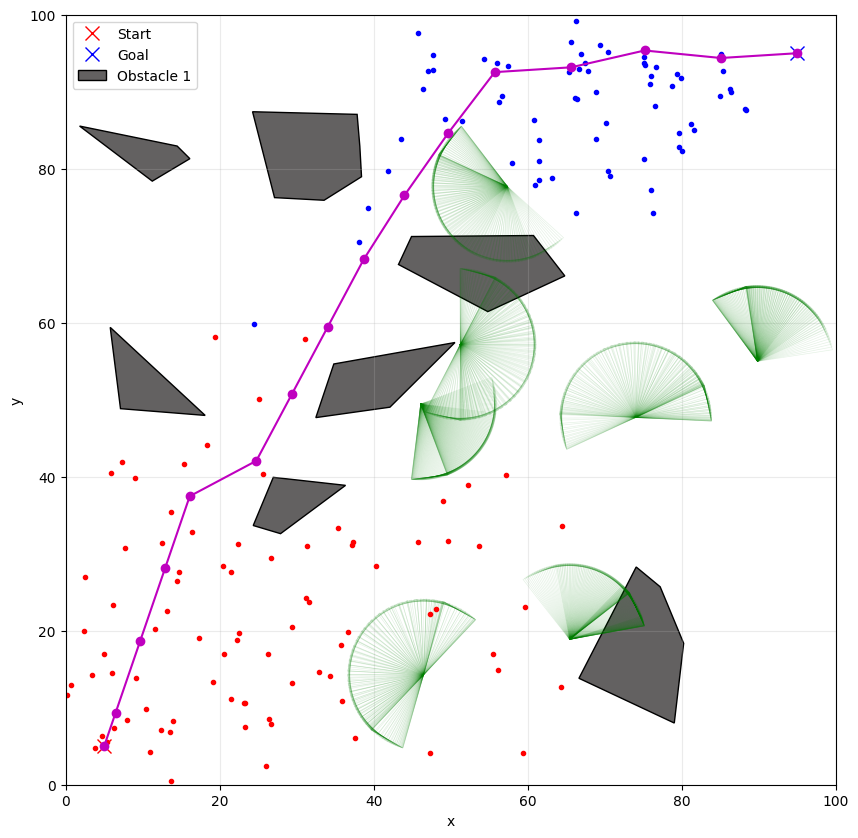

In [31]:
# UNCOMMENT in Jupyter
%matplotlib inline 

'''Uncomment this to go back to getting the paths from the files (From the monte carlo simulation)'''
# if path_type_string == "naive":
#     end_point_naive = [xf[0], xf[1], min_time*5]
#     path = [x0_1, end_point_naive]
# else:
#     path = path_data[path_type_string][str(scenario_key)]  # or whichever key you want to use

# V_goal = path[-1]
# V_start = path[0]

# --------------------------- RRT Visualization ------------------------------------------------#
figure = plt.figure(figsize=(10, 10), dpi = 500)
fig, ax = plt.subplots(figsize=(10, 10))
pointmarker = 10

plt.plot(x0list[0][0], x0list[0][1], 'xr', markersize=pointmarker, label='Start')
plt.plot(xf[0], xf[1], 'xb', markersize=pointmarker, label='Goal')

# Timestamps for fov triangles
num_fov = np.ceil(tfn*5)  # number of time steps (Currently at 5 Hz sampling)
if path != None:
    start_time = path[0][2]
    end_time = path[len(path)-1][2]
else:
    start_time = 0
    end_time = tfn*10
t_fov = np.linspace(start_time, end_time, num_fov+1)

# # helper funciton to pass a camera dictionary with only the fov bounds and initial angle for that particular camera
# def make_single_cam_dict(cam_dict, cam_index):
#     return {
#         'x': [cam_dict['x'][cam_index]],
#         'y': [cam_dict['y'][cam_index]],
#         'n': 1,
#         'spec': {
#             'bound': cam_dict['spec']['bound'][cam_index],
#             'fov': cam_dict['spec']['fov'],
#             'cam_time': cam_dict['spec']['cam_time'],
#             'init_angle': cam_dict['spec']['init_angle'][cam_index]
#         }
#     }


# for t in t_fov:
#     for ii in range(len(cam_x)):
#         # Preprocess cam_dict for this camera
#         cam_dict_single = make_single_cam_dict(cam_dict, ii)

#         # Create a temporary DynamicMap with just one camera
#         temp_map = {
#             'n': cam_dict['spec']['cam_time'][0],  # camera period
#             'ncam': 1,
#             'x': [cam_x[ii]],
#             'y': [cam_y[ii]]
#         }

#         temp_dmap = DynamicMap(temp_map, cam_dict_single)
#         cameras_dmap = temp_dmap.gen_cam(t)

#         cam_i_fov_poly = cameras_dmap['0']['FOV_Poly']  # only one camera

#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)



# # Old version with issues passing a full list to the dmap
# for t in t_fov:
#     for ii in range(len(cam_x)):
#         cameras_dmap = dmap.gen_cam(ii, t)
#         #ncam = cameras_dmap['n']
#         cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)

for t in t_fov:
    for ii in range(len(cam_x)):
        cameras_dmap = dmap.gen_cam(ii, t)
        cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
        cx, cy = cam_i_fov_poly.exterior.xy
        plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)
        
building_alpha = 1
# Define colors for the convex obstacles
obstacle_colors = ["#636161", "#636161"] # Gray colors
camera_color = ['#008000', '#7FFF00', '#9ACD32', "#00EAFF", "#065AEC", "#9406EC", "#EC06EC", "#EC0694", "#EC8806", "#EC0E06"]

# for ii in range(map_in['st']['n']):
#     ibuilding = map_in['st'][str(ii)]
#     #camera_circle = plt.Circle((ibuilding[0], ibuilding[1]), ibuilding[2], color=camera_color[ii], alpha=building_alpha, clip_on=False, label='PTZCAM0'+str(ii+1))
#     #ax.add_patch(camera_circle) 

for ii in range(map_in['st']['n']):
    # map_in['st'][str(ii)] contains the (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(ii)]
    
    # Create a Polygon patch from the vertices
    # Use a solid fill color (facecolor) and a darker edge (edgecolor)
    polygon_patch = patches.Polygon(
        poly_vertices,
        closed=True,
        facecolor=obstacle_colors[ii % len(obstacle_colors)], # Cycle through colors
        edgecolor='k',
        linewidth=1,
        alpha=building_alpha,
        label=f'Obstacle {ii+1}' if ii == 0 else "" # Only label the first one for legend
    )
    ax.add_patch(polygon_patch)


# Plot RRT

# Ignoring vertex plotting, I only care about the final path
for vi in V_start:
    plt.plot(vi[0], vi[1], '.r')
for i in range(len(V_goal)):
    for vi in V_goal[str(i)]:
        plt.plot(vi[0], vi[1], '.b')

# Plot Path
for pi in path:
    plt.plot(pi[0], pi[1], 'om')

for pii in range(len(path)-1):
    p1 = path[pii]
    p2 = path[pii+1]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], '-m')


plt.grid(alpha=0.25)
plt.axis('square')
# Plot Limits
plt.xlim(map_size[0], map_size[1])
plt.ylim(map_size[2], map_size[3])
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()
# fig.savefig('crazyflie_test_map.png')


CasADi Optimization

In [32]:
# CasADi

# Cost function: at each time step, take the pointwise probability of detection k(x,t) where x is the
# position and t is the time. 
# P_detection = 1 - P_not_detected
# P_not_detected = (1-k(x1,t1))*(1-k(x2,t2))*(1-k(x3,t3))*...
# P_not_detected = PI(1-k(x_i, t_i))
# log(P_not_detected) = log(PI(1-k(x_i, t_i)))
# log(P_not_detected) = log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ...
# So, at each time step, take the pointwise detectability, then take the log of it, then add it to the running cost
# CasADi should try to MAXIMIZE this summation of logarithms to minimize the probability of detection

# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected


# Gemini alpha calculation:
# alpha ~= 99/range_max^2

tic = time.time()


alpha = 99/(fov_rng**2)#this is the distance decay variable (higher = more decay) 
# ^ (Currently, this does the math to make the k value <=0.01 outside of fov range)
c = 100 #this is the steepness of visibility transition (higher = sharper transition)

#MAX_K_VALUE = 0.9999

# New version, uses call to Camera.py to find FOV center:
def calculate_k_value(xi, yi, ti, camera_objects):
    total_cost = 0
    for cam in camera_objects:
        cam_x, cam_y = cam.cam_position()
        phi = cam.get_ctr_theta_t(ti)  # Use Camera.py method

        theta = cam.fov_ang
        dx = xi - cam_x
        dy = yi - cam_y
        dist2 = dx**2 + dy**2
        # dist = ca.sqrt(dist2 + 1e-6)

        dist_min_sq = ca.fmax(dist2, 1e-4) #try putting this back to 1e-4 if the optimization works
        dist_safe = ca.sqrt(dist_min_sq)

        cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist_safe
        visibility = 1 / (1 + ca.exp(-c * (cos_alpha - ca.cos(theta / 2))))
        observability = 1 / (1 + alpha * dist_min_sq)
        total_cost += visibility * observability
    # return ca.fmin(total_cost,MAX_K_VALUE) # This prevents ln(0) issues which break the solver
    return total_cost

opti = ca.Opti()


# MULTIPLE SHOOTING TIME BABYYYYY

# --- 1. Use RRT Path Directly for Parameters ---
# Extract arrays from the RRT path list [[x,y,t], ...]
path_arr = np.array(path)
rrt_x = path_arr[:, 0]
rrt_y = path_arr[:, 1]
rrt_t = path_arr[:, 2]

# Set N_shooting based on the number of segments in the RRT path
N_shooting = len(path) - 1 
M_steps = 100  # Integration steps per interval (keep this high for collision safety)
N = N_shooting * M_steps  # Total number of time steps (for plotting later)

# --- Decision Variables ---
# State: [x, y, t] at the boundaries of shooting intervals
X = opti.variable(3, N_shooting + 1)
pos_x = X[0, :]
pos_y = X[1, :]
current_t = X[2, :]

# Controls: [v_x, v_y] for each shooting interval
U = opti.variable(2, N_shooting)

# Interval Duration: Time duration of each shooting interval
T_interval = opti.variable(N_shooting)

# --- Initial/Final Constraints ---
opti.subject_to(pos_x[0] == x0_1[0])
opti.subject_to(pos_y[0] == x0_1[1])
opti.subject_to(current_t[0] == x0_1[2])

opti.subject_to(pos_x[-1] == xf[0])
opti.subject_to(pos_y[-1] == xf[1])

# --- Generate Camera Objects ---
camera_objects = []
for i in range(cam_dict['n']):
    cam_obj = Camera(i, cam_dict, cam_dict['x'][i], cam_dict['y'][i])
    camera_objects.append(cam_obj)

# --- Multiple Shooting Loop ---
log_sum = 0
epsilon = 1e-6
vmax = vehicle['v']
dt_min = 1e-4 

vehicle_radius = 0 # vehicle['radius'] # From vehicle setup             # PUT THIS BACK!!!
buffer_dist = 0    # Extra buffer; Adjust this in both the rrt step and casadi step (make sure they match)
safety_margin = vehicle_radius + buffer_dist

gamma = 500 # smoothing factor for log-sum-exp approximation

for k in range(N_shooting): # Iterating over each rrt point
    # 1. Get state at start of interval k
    st = X[:, k]  
    # 2. Get control for interval k
    v_k = U[:, k] 
    
    # 3. Time integration step size for this interval
    dt = T_interval[k] / M_steps
    opti.subject_to(dt >= dt_min)
    
    # 4. Integrate forward M steps (Euler Integration)
    for j in range(M_steps):
        # Cost at current position and time
        k_val = calculate_k_value(st[0], st[1], st[2], camera_objects)
        log_sum += ca.log(ca.fmax(1 - k_val, epsilon))
        
        # Map Bounds
        opti.subject_to(opti.bounded(map_size[0], st[0], map_size[1]))
        opti.subject_to(opti.bounded(map_size[2], st[1], map_size[3]))
        
        # Static Obstacles
        p_k = st[0:2] 
        for obs_data in obstacle_constraints:
            A = obs_data['A']
            b = obs_data['b']
            h_i_vector = ca.mtimes(A, p_k) - b
            
            # Number of edges in this specific polygon
            num_edges = A.shape[0]

            # Log-Sum-Exp Constraint for Obstacle avoidance
            max_h = h_i_vector[0]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_i_vector[idx])
            
            lse_term = max_h + (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * (h_i_vector - max_h))))

            # --- THE FIX: SUBTRACT THE SMOOTHING ERROR ---
            # We subtract log(num_edges)/gamma to ensure the constraint is strict.
            # This closes the "numerical gap" at the corners.
            lse_debiased = lse_term - (ca.log(num_edges) / gamma)

            # opti.subject_to(lse_term >= safety_margin)
            opti.subject_to(lse_debiased >= safety_margin)

        # Dynamics Update (Euler)
        # x_next = x + v_x * dt
        st[0] = st[0] + v_k[0] * dt # x update
        st[1] = st[1] + v_k[1] * dt # y update
        st[2] = st[2] + dt          # t update

    # 5. Continuity Constraint (between shooting intervals)
    opti.subject_to(X[:, k+1] == st)
    
    # 6. Velocity Constraint
    opti.subject_to(v_k[0]**2 + v_k[1]**2 <= vmax**2)

# --- Total Time Constraint ---
T_total = ca.sum(T_interval) # This probably needs to be ca.sum1(ca.sum2())
opti.subject_to(T_total <= end_time)

# --- Objective ---
time_penalty = 0 #0.01 * T_total # Switch this back eventually
J_total_cost = log_sum - time_penalty 
opti.minimize(-J_total_cost)

# --- 2. Set Initial Guesses Directly from RRT Data ---

# State Guess: The RRT nodes exactly align with our X variables
X_init = ca.vertcat(rrt_x, rrt_y, rrt_t)
opti.set_initial(pos_x, rrt_x)
opti.set_initial(pos_y, rrt_y)
opti.set_initial(current_t, rrt_t)

# Calculate differentials for Control/Time guesses
dx_guess = np.diff(rrt_x)
dy_guess = np.diff(rrt_y)
dt_guess = np.diff(rrt_t)

# Prevent division by zero if RRT has duplicate time stamps (rare but possible)
dt_guess = np.maximum(dt_guess, 1e-4)

vx_guess = dx_guess / dt_guess
vy_guess = dy_guess / dt_guess

# Control Guess

U_init = [vx_guess, vy_guess]

opti.set_initial(U[0, :], vx_guess)
opti.set_initial(U[1, :], vy_guess)

# Time Interval Guess
T_interval_init = dt_guess
opti.set_initial(T_interval, dt_guess)










# # --- Solve ---
# p_opts = {"expand": True}
# s_opts = {
#     "max_iter": 3000,
#     "tol": 1e-5,
#     "acceptable_tol": 1e-4,
#     "print_level": 5
# }
# opti.solver("ipopt", p_opts, s_opts)

# try:
#     sol = opti.solve()
    
#     # Extract solution
#     x_nodes = sol.value(pos_x)
#     y_nodes = sol.value(pos_y)
#     t_nodes = sol.value(current_t)
    
#     # For plotting, We need to reconstruct the full dense path from the shooting nodes + integration
#     # Since we used Euler, we can just linearly interpolate between the shooting nodes

#     # Densify path for plotting
#     x_opt = []
#     y_opt = []
#     t_opt_num = []
    
#     for k in range(N_shooting):
#         x_seg = np.linspace(x_nodes[k], x_nodes[k+1], M_steps, endpoint=False)
#         y_seg = np.linspace(y_nodes[k], y_nodes[k+1], M_steps, endpoint=False)
#         t_seg = np.linspace(t_nodes[k], t_nodes[k+1], M_steps, endpoint=False)
        
#         x_opt.extend(x_seg)
#         y_opt.extend(y_seg)
#         t_opt_num.extend(t_seg)
    
#     # Append final node
#     x_opt.append(x_nodes[-1])
#     y_opt.append(y_nodes[-1])
#     t_opt_num.append(t_nodes[-1])
    
#     # Probability of Detection Calculation
#     final_log_sum_value = sol.value(log_sum)
#     final_P_detection = 1 - np.exp(final_log_sum_value)
    
#     print(f"Final Probability of Detection: {final_P_detection:.4f}")
    
# except RuntimeError as e:
#     print("Solver failed:", e)
















# # # Set timestamps
# # #N = 2000  # number of time steps (tune this)
# # #N = 400
# # # # total travel time T is a decision variable (>= small positive)
# # # T = opti.variable()
# # # dt = T / N

# # # --- NEW: Replace with variable time steps ---
# # # Vector of time steps (one for each segment)
# # Delta_t = opti.variable(N)  # N segments = N Delta_t variables

# # # Total time is now an expression
# # T_total = ca.sum(Delta_t) 

# # # Start time of the path
# # t_start_node = x0_1[2] # This is 0 in your setup, but good practice to reference it

# # # Cumulative time at each node (t_0, t_1, ..., t_N)
# # # t_nodes[i] will be the time at position (x[i], y[i])
# # # The initial time t_nodes[0] is fixed at t_start_node
# # t_nodes = [t_start_node] 
# # for i in range(N):
# #     # This iteratively defines t_i = t_{i-1} + Delta_t_{i-1}
# #     t_nodes.append(t_nodes[-1] + Delta_t[i]) 

# # # Decision variables
# # x = opti.variable(N+1)  # UAV x coords
# # y = opti.variable(N+1)  # UAV y coords


# # # Initial position constraints
# # opti.subject_to(x[0] == x0_1[0])
# # opti.subject_to(y[0] == x0_1[1])
# # # Final position constraints
# # opti.subject_to(x[-1] == xf[0])
# # opti.subject_to(y[-1] == xf[1])

# # # Map bounds
# # opti.subject_to(opti.bounded(map_size[0], x, map_size[1]))
# # opti.subject_to(opti.bounded(map_size[2], y, map_size[3]))

# # # --- Update Max Speed Constraint (Crucial Change) ---
# # vmax = vehicle['v']
# # for i in range(N):
# #     dx = x[i+1] - x[i]
# #     dy = y[i+1] - y[i]
# #     # Each segment's distance is constrained by its own variable time step:
# #     opti.subject_to(dx**2 + dy**2 <= (vmax * Delta_t[i])**2)

# # # Old Max speed constraint (for constant dt)
# # vmax = vehicle['v']
# # for i in range(N):
# #     dx = x[i+1] - x[i]
# #     dy = y[i+1] - y[i]
# #     opti.subject_to(dx*dx + dy*dy <= (vmax*dt)**2)

# # # --- Time Constraints ---
# # # 1. Minimum time step (prevents solver from choosing Delta_t = 0, which breaks division/derivatives)
# # dt_min = 1e-5 # A small minimum time step is necessary
# # opti.subject_to(Delta_t >= dt_min)  
# # opti.subject_to(T_total <= end_time) # Path arrives at end point in the same time or less than the RRT guess








# # # Static Obstacle Avoidance Constraints
# # safety_margin = 0.1 # Agent radius + desired clearance (tune this)
# # gamma = 100000  # Smoothing parameter for LogSumExp (LSE) approximation of max
# # """UPDATE THIS"""


# # for k in range(N + 1): # Check all N+1 path nodes
# #     p_k = ca.vertcat(x[k], y[k])
    
# #     for obs_data in obstacle_constraints:
# #         A = obs_data['A']
# #         b = obs_data['b']
        
# #         # h_i_vector is (N_edges, 1) and contains a_i^T * p_k - b_i for each edge i
# #         h_i_vector = ca.mtimes(A, p_k) - b
        
# #         '''Updated way that does numerically stable LogSumExp'''
# #         # 1. Find the symbolic maximum of the vector h_i_vector
# #         # This is required for the numerically stable LSE
# #         max_h_val = h_i_vector[0]
# #         for i in range(1, A.shape[0]):
# #             max_h_val = ca.fmax(max_h_val, h_i_vector[i])

# #         # 2. Calculate the Numerically Stable LogSumExp (LSE)
# #         # LSE(h) = max(h) + (1/gamma) * log(sum(exp(gamma * (h_i - max(h)))))
# #         centered_h_vector = h_i_vector - max_h_val
        
# #         lse_term = max_h_val + (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * centered_h_vector)))
        
# #         # 3. Constraint: LSE(h) >= safety_margin
# #         # Ensures the maximum violation (i.e., the point p_k being OUTSIDE the obstacle)
# #         # is greater than the required clearance.
# #         opti.subject_to(lse_term >= safety_margin)


# #         '''Slightly less old way that uses LogSumExp'''
# #         # # SMOOTH APPROXIMATION OF MAX: LogSumExp (LSE)
# #         # # LSE(h_i) = (1/gamma) * log(sum(exp(gamma * h_i)))
# #         # # This approximates max_i(h_i)
        
# #         # # If max_i(h_i) is large and positive, the point is outside (safe)
# #         # # If max_i(h_i) is negative, the point is inside (collision)
        
# #         # # NOTE on numerical stability: Max(h_i) is approximated as 
# #         # # (1/gamma) * log(sum(exp(gamma * (h_i - max(h_i))))) + max(h_i)
# #         # # However, CasADi's built-in log(sum(exp)) is usually numerically safe enough.
# #         # # We'll use the simpler, direct form:
# #         # lse_term = (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * h_i_vector)))
        
# #         # # Constraint is max_h >= safety_margin
# #         # # Replaced the non-smooth ca.fmax constraint with the smooth LSE constraint
# #         # opti.subject_to(lse_term >= safety_margin)


# #         '''Old way that uses fmax '''
# #         # Symbolic matrix multiplication for h_i(p_k) = A * p_k - b
# #         # A is (N_edges, 2), p_k is (2, 1), b is (N_edges, 1)
# #         h_i_vector = ca.mtimes(A, p_k) - b
        
# #         # Max violation across all edges: max_i(a_i^T * p_k - b_i)
# #         # If this value is positive, the point is OUTSIDE the polygon
# #         # (on the wrong side of the edge that defines the max violation).
# #         # THIS IS NOT THE CORRECT CONSTRAINT for a single convex polygon.
        
# #         # Correct constraint for a CONVEX obstacle:
# #         # The agent p_k is *inside* the polygon if AND only if:
# #         # a_i^T * p_k <= b_i for ALL i
# #         # This means we need N_edges separate constraints for each time step k.
        
# #         # Constraint form for CasADi: g_i(p_k) <= 0
# #         # We define g_i(p_k) = a_i^T * p_k - b_i
        
# #         # Constraint must be: max_i(a_i^T * p_k - b_i) >= safety_margin
# #         # to ensure the point p_k is OUTSIDE the convex obstacle (A*p <= b)
        
# #         # Symbolic matrix multiplication for h_i(p_k) = A * p_k - b
# #         # h_i_vector is (N_edges, 1) and contains a_i^T * p_k - b_i for each edge i
# #         h_i_vector = ca.mtimes(A, p_k) - b
        
# #         # Max violation across all edges: max_i(a_i^T * p_k - b_i)
# #         # We want this maximum value to be >= safety_margin.
        
# #         # Use ca.fmax repeatedly to compute the element-wise maximum
# #         # Start with the first element
# #         max_h = h_i_vector[0]
# #         for i in range(1, h_i_vector.shape[0]):
# #             max_h = ca.fmax(max_h, h_i_vector[i])
            
# #         # Constraint is max_h >= safety_margin
# #         opti.subject_to(max_h >= safety_margin)


# # # Generating Camera objects
# # camera_objects = []
# # for i in range(cam_dict['n']):
# #     cam_obj = Camera(i, cam_dict, cam_dict['x'][i], cam_dict['y'][i])
# #     camera_objects.append(cam_obj)

# # # New cost (I guess maybe it's a "utility"):
# # log_sum = 0
# # epsilon = 1e-6 #adding this for numerical stability
# # for i in range(N):
# #     #t_i = start_time + i * dt
# #     t_i = t_nodes[i]
# #     k_value = calculate_k_value(x[i], y[i], t_i, camera_objects) # generating pointwise detectability

# #     #current_log_term = ca.log(1 - k_value)

# #     # # Add a small epsilon to the argument to prevent log(0)
# #     # epsilon = 1e-6 
# #     current_log_term = ca.log(ca.fmax(1 - k_value, epsilon)) # Preventing log(0) errors
# #     # current_log_term = ca.log(1 - k_value)

# #     log_sum += current_log_term

# # Cost function: at each time step, take the pointwise probability of detection k(x,t) where x is the
# # position and t is the time. 
# # P_detection = 1 - P_not_detected
# # P_not_detected = (1-k(x1,t1))*(1-k(x2,t2))*(1-k(x3,t3))*...
# # P_not_detected = PI(1-k(x_i, t_i))
# # log(P_not_detected) = log(PI(1-k(x_i, t_i)))
# # log(P_not_detected) = log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ...
# # So, at each time step, take the pointwise detectability, then take the log of it, then add it to the running cost
# # CasADi should try to MAXIMIZE this summation of logarithms to minimize the probability of detection
# # So, minimize the negative of the log_sum


# # time penalty to encourage shorter time
# time_penalty = 0 #0.02*T_total
# # I want this to make the path smoother without affecting the probability of detection
# # Looks like 0.01 is a reasonable choice
# # 0: 0.383 pd
# # 0.01: 0.366
# # 0.02: 0.4 pd
# # I'm going with that for now ^^

# J_total_cost = log_sum - time_penalty # We want to maximize the log sum, so the time penalty should be signed opposite from log_sum

# opti.minimize(-J_total_cost) # We want to MAXIMIZE the log sum, so we minimize the negative of the total cost


# # Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# # log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# # exp(log(P_not_detected)) = P_not_detected
# # P_detected = 1 - P_not_detected

def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
    """
    Interpolates the original STP-RRT path using time-based interpolation,
    preserving the original speed profile.

    Parameters:
    - rrt_path: list of [x, y, t] points from STP-RRT
    - num_points: number of interpolated points to generate

    Returns:
    - x_interp: list of interpolated x positions
    - y_interp: list of interpolated y positions
    - t_interp: list of interpolated time values
    """
    rrt_array = np.array(rrt_path)
    x = rrt_array[:, 0]
    y = rrt_array[:, 1]
    t = rrt_array[:, 2]

    # Create interpolation functions for x(t) and y(t)
    fx = interp1d(t, x, kind='linear')
    fy = interp1d(t, y, kind='linear')

    # Generate evenly spaced time values
    t_interp = np.linspace(t[0], t[-1], num_points)

    # Interpolate positions
    x_interp = fx(t_interp)
    y_interp = fy(t_interp)

    return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()



# # Interpolating RRT initial guess
x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)


# ... (previous code for setting up opti, X, U, T_interval, and the loop) ...

# --- RE-IMPLEMENTED EVALUATOR ---

# 1. Define a CasADi function that takes the distinct matrices as inputs
# Inputs: X (3 x N+1), U (2 x N), T_interval (N)
# Outputs: log_sum, time_penalty
cost_evaluator = ca.Function('cost_evaluator', [X, U, T_interval], [log_sum, time_penalty])

# 2. Prepare Numerical Initial Guesses
# X_init needs to be shape (3, N_shooting+1)
X_num_init = np.vstack([rrt_x, rrt_y, rrt_t]) 

# U_init needs to be shape (2, N_shooting)
U_num_init = np.vstack([vx_guess, vy_guess])

# T_init needs to be shape (N_shooting,)
T_num_init = dt_guess

# 3. Calculate Initial Probability
init_log_sum_dm, init_penalty_dm = cost_evaluator(X_num_init, U_num_init, T_num_init)
init_log_sum_val = float(init_log_sum_dm)

initial_P_detection = 1 - np.exp(init_log_sum_val)



# --- Solve Optimization ---
p_opts = {"expand": True}
s_opts = {
    "max_iter": 3000,
    "tol": 1e-7, # 1e-5,
    "acceptable_tol": 1e-5, # 1e-4,
    "constr_viol_tol": 1e-7, # Ensure constraint violation is minimal
    "print_level": 5
}
opti.solver("ipopt", p_opts, s_opts)

try:
    sol = opti.solve()
    
    # Extract solution values
    X_num_opt = sol.value(X)
    U_num_opt = sol.value(U)
    T_num_opt = sol.value(T_interval)
    
    # 4. Calculate Final Probability using the same evaluator
    final_log_sum_dm, final_penalty_dm = cost_evaluator(X_num_opt, U_num_opt, T_num_opt)
    final_log_sum_val = float(final_log_sum_dm)
    
    final_P_detection = 1 - np.exp(final_log_sum_val)

    # Prepare plotting data (reconstruct dense path)
    x_nodes = X_num_opt[0, :]
    y_nodes = X_num_opt[1, :]
    t_nodes = X_num_opt[2, :]
    
    x_opt = []
    y_opt = []
    t_opt_num = []
    
    # Linearly interpolate between shooting nodes for visualization
    for k in range(N_shooting):
        x_seg = np.linspace(x_nodes[k], x_nodes[k+1], M_steps, endpoint=False)
        y_seg = np.linspace(y_nodes[k], y_nodes[k+1], M_steps, endpoint=False)
        t_seg = np.linspace(t_nodes[k], t_nodes[k+1], M_steps, endpoint=False)
        
        x_opt.extend(x_seg)
        y_opt.extend(y_seg)
        t_opt_num.extend(t_seg)
    
    # Append final point
    x_opt.append(x_nodes[-1])
    y_opt.append(y_nodes[-1])
    t_opt_num.append(t_nodes[-1])

except RuntimeError as e:
    print("Solver failed:", e)
    # Fallback to debug values if solve fails
    x_opt = opti.debug.value(pos_x)
    y_opt = opti.debug.value(pos_y)
    t_opt_num = opti.debug.value(current_t)
    final_P_detection = 1.0 # Sentinel value

toc = time.time() - tic
print(f"Initial Probability of Detection: {initial_P_detection:.4f}")
print(f"Final Probability of Detection: {final_P_detection:.4f}")
print(f"Time to calculate: {toc:.4f} s")






# # Using time interpolated RRT as the initial guess
# opti.set_initial(x, x_interp)
# opti.set_initial(y, y_interp)

# # # T initial guess
# # T_init = float(path[-1][2] - path[0][2])
# # opti.set_initial(T, T_init)

# # --- Update Initial Guess for Time ---
# T_init = float(path[-1][2] - path[0][2])
# # Distribute the total RRT time evenly across the N segments
# Delta_t_init_value = T_init / N 
# opti.set_initial(Delta_t, Delta_t_init_value) # Sets all Delta_t[i] to this value
# Delta_t_init_vector = np.full(N, Delta_t_init_value).tolist()


# #TODO Uncomment this section
# # CasADi function to calculate detection probability of a path:
# # 4. Get the full symbolic decision variable vector (x,y,t,M,)
# w_sym = ca.vertcat(X,U,T_interval) 

# # 5. this calculates the log sum for a particular path
# log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym], [log_sum])

# # 6. This calculates the time pnalty term for a particular path
# penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym], [time_penalty])

# # Calculating Probability of Detection for initial path:
# # Prepare the numerical initial guess vector (w0)
# w0 = ca.vertcat(X_init,U_init,T_interval_init) # X, U, T_interval initial guesses

# # Evaluate the log sum for the initial path
# initial_log_sum_dm = log_sum_evaluator(w0)
# initial_log_sum_value = initial_log_sum_dm.full().item()

# # Evaluate the Penalty Cost for the initial path
# initial_penalty_cost_dm = penalty_cost_evaluator(w0)
# initial_penalty_cost_value = initial_penalty_cost_dm.full().item()

# # Calculate the inital probability of detection of the path:
# # Calculate and Report Results:
# initial_P_non_detection = np.exp(initial_log_sum_value)
# initial_P_detection = 1 - initial_P_non_detection
# initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected
# so P_detected = 1 - exp(log_sum)



# # # Solver options
# # p_opts = {"expand": True}
# # s_opts = {
# #     "max_iter": 3000,
# #     "tol": 1e-6,
# #     "acceptable_tol": 1e-4,
# #     "print_level": 5
# #     #"constr_viol_tol": 1e-2,  # Increase from default 1e-4 (e.g., to 1e-3)
# #     #"acceptable_constr_viol_tol": 1e-1 # Loosen this up as well
# # }

# # opti.solver("ipopt", p_opts, s_opts)

# # # Solve
# # try:
# #     sol = opti.solve()
# #     x_opt = sol.value(x)
# #     y_opt = sol.value(y)
# #     Delta_t_opt = sol.value(Delta_t)
# #     log_sum_opt = sol.value(log_sum)
# # except RuntimeError as e:
# #     print("Solver failed:", e)
# #     x_opt = opti.debug.value(x)
# #     y_opt = opti.debug.value(y)
# #     Delta_t_opt = opti.debug.value(Delta_t)
# #     log_sum_opt = opti.debug.value(log_sum)

# # Calculating final probability of detection
# # Prepare the numerical final guess vector (wf)
# wf = ca.vertcat(x_opt, y_opt, Delta_t_opt)

# # Evaluate the log sum for the final path
# final_log_sum_dm = log_sum_evaluator(wf)
# final_log_sum_value = final_log_sum_dm.full().item()

# # Evaluate the Penalty Cost for the final path
# final_penalty_cost_dm = penalty_cost_evaluator(wf)
# final_penalty_cost_value = final_penalty_cost_dm.full().item()

# # Calculate the inital probability of detection of the path:
# # Calculate and Report Results:
# final_P_non_detection = np.exp(final_log_sum_value)
# final_P_detection = 1 - final_P_non_detection
# final_total_cost = final_log_sum_value - final_penalty_cost_value

# # Build a numeric time vector for export/animation
# # t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
# t_opt_num = np.cumsum(np.insert(Delta_t_opt, 0, x0_1[2]))

# # Final output: list of [x, y, t]
# optimized_path = list(zip(x_opt, y_opt, t_opt_num))



# # print(f"Final log_sum value: {final_log_sum_value:.4f}")
# # print(f"Final Time Penalty: {final_penalty_cost_value:.4f}")
# # print(f"Final Total Cost (J): {final_total_cost:.4f}")
# print(f"Initial Probability of Detection: {initial_P_detection:.4f}")
# print(f"Final Probability of Detection: {final_P_detection:.4f}")


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      170
Number of nonzeros in inequality constraint Jacobian.:    61185
Number of nonzeros in Lagrangian Hessian.............:      315

Total number of variables............................:       93
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       50
Total number of inequality constraints...............:    13531
        inequality constraints with only lower bounds:    10515
   inequality constraints with lower and upper bounds:     3000
        inequality constraints with only upper bounds:       16

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.4068009e-01 6.39e-13 1.25e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

File Export for Path Comparison

In [33]:
# === Save original speed RRT path ===
interpolated_path = list(zip(x_interp, y_interp, t_interp))
with open('rrt_original_path.csv', 'w', newline='') as f_out:
    writer = csv.writer(f_out)
    writer.writerow(['x', 'y', 't'])
    for xi, yi, ti in interpolated_path:
        writer.writerow([xi, yi, ti])

# === Save optimized path ===
with open('optimized_path.csv', 'w', newline='') as f_opt:
    writer = csv.writer(f_opt)
    writer.writerow(['x', 'y', 't'])
    for xo, yo, to in zip(x_opt, y_opt, t_opt_num):
        writer.writerow([xo, yo, to])



theta = cam_dict['spec']['fov'][0] # Currently assuming all cameras have the same FOV angle
fov_range = cam_dict['spec']['fov'][1] # Currently assuming all cameras have the same FOV range

# # Save camera parameters to a JSON file
# simulation_parameters = {
#     "theta": float(theta),  # Convert from numpy/casadi type if needed
#     "k": float(k),
#     "alpha": float(alpha),
#     "cameras_dict_copilot": cameras_dict_copilot,
#     "map_size": map_size,
#     "fov_range": fov_range
# }

# Add panspeed to each camera dictionary
for i, cam in enumerate(cameras_dict_copilot):
    cam["panspeed"] = cam_dict["spec"]["panspeed"][i]

# Extract static obstacle vertices in a serializable format
static_obstacles_for_export = []
num_static_obs = map_in['st']['n']

# map_in['st'] stores vertices under keys '0', '1', ... as NumPy arrays
for i in range(num_static_obs):
    # Convert the numpy array of vertices (N_verts, 2) to a list of lists (which is JSON serializable)
    vertices_list = map_in['st'][str(i)].tolist() 
    static_obstacles_for_export.append(vertices_list)

# Save camera parameters to a JSON file
simulation_parameters = {
    "theta": float(theta),
    "c": float(c),
    "alpha": float(alpha),
    "cameras_dict_copilot": cameras_dict_copilot,
    "map_size": map_size,
    "fov_range": fov_range,
    "initial_P_detection": initial_P_detection,
    "final_P_detection": final_P_detection,
    "static_obstacles": static_obstacles_for_export
}
with open("simulation_parameters.json", "w") as f:
    json.dump(simulation_parameters, f, indent=4)
print("Simulation parameters saved to simulation_parameters.json.")

Simulation parameters saved to simulation_parameters.json.
